<a href="https://colab.research.google.com/github/balasri03/Mini_project/blob/main/review_pstance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import re
import torch
from torch.nn.utils.rnn import pad_sequence
from collections import Counter
import pandas as pd
import time
from collections import Counter
import numpy as np

In [ ]:
train_df = pd.read_csv("trainmerged (4).csv")
val_df = pd.read_csv("/content/valmerged (3).csv")
test_df = pd.read_csv("/content/testmerged (3).csv")

In [ ]:
train_df.shape

(17224, 3)

In [ ]:
print(train_df.columns)

Index(['Tweet', 'Target', 'Stance'], dtype='object')


In [ ]:
print(train_df["Stance"].value_counts())

Stance
AGAINST    8877
FAVOR      8347
Name: count, dtype: int64


In [ ]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

17224
2193
2157


In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)          # remove URLs
    text = re.sub(r"@\w+", "", text)                    # remove mentions
    text = re.sub(r"#", "", text)                       # remove hashtags
    text = re.sub(r"[^a-z\s]", "", text)                # keep only letters
    text = re.sub(r"\s+", " ", text).strip()            # remove extra spaces
    return text


train_df["clean_text"] = (train_df["Tweet"] + " " + train_df["Target"]).apply(clean_text)

val_df["clean_text"] = (val_df["Tweet"] + " " + val_df["Target"]).apply(clean_text)

test_df["clean_text"] = (test_df["Tweet"] + " " + test_df["Target"]).apply(clean_text)

In [ ]:
from collections import Counter

def build_vocab(texts, min_freq=5):
    counter = Counter()

    for text in texts:
        words = text.split()
        counter.update(words)

    vocab = {"<pad>": 0, "<unk>": 1}

    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)

    return vocab


vocab = build_vocab(train_df["clean_text"])

In [ ]:
def text_to_seq(text, vocab):
    words = text.split()

    return [
        vocab.get(word, vocab["<unk>"])
        for word in words
    ]

In [ ]:
train_df["input_text"] = train_df["clean_text"] + " " + train_df["Target"]
val_df["input_text"]   = val_df["clean_text"]   + " " + val_df["Target"]
test_df["input_text"]  = test_df["clean_text"]  + " " + test_df["Target"]

vocab = build_vocab(train_df["input_text"].tolist())

print(f"Vocab size: {len(vocab)}")

Vocab size: 6488


In [ ]:
len(train_df['input_text'])

17224

In [ ]:
label_col = "Stance"

unique_labels = sorted(train_df[label_col].unique())

label2id = {label: idx for idx, label in enumerate(unique_labels)}

id2label = {v: k for k, v in label2id.items()}

print("Label mapping:", label2id)

Label mapping: {'AGAINST': 0, 'FAVOR': 1}


In [ ]:
train = train_df["input_text"]
len(train)

17224

In [ ]:
test = test_df["input_text"]
len(test)

2157

In [ ]:
val = val_df["input_text"]
len(val)

2193

LSTM BASELINE

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.layers import Input, Embedding
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import SpatialDropout1D

In [ ]:
X_train = [text_to_seq(text, vocab) for text in train_df["input_text"]]
X_val   = [text_to_seq(text, vocab) for text in val_df["input_text"]]
X_test  = [text_to_seq(text, vocab) for text in test_df["input_text"]]

In [ ]:
max_len = 50

X_train_pad = pad_sequences(X_train, maxlen=max_len, padding="post")
X_val_pad   = pad_sequences(X_val, maxlen=max_len, padding="post")
X_test_pad  = pad_sequences(X_test, maxlen=max_len, padding="post")

In [ ]:
y_train = train_df["Stance"].map(label2id).values
y_val   = val_df["Stance"].map(label2id).values
y_test  = test_df["Stance"].map(label2id).values

In [ ]:
vocab_size = len(vocab)
embedding_dim = 50

model = Sequential()

model.add(Input(shape=(max_len,)))

model.add(Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
))

model.add(SpatialDropout1D(0.2))

model.add(LSTM(32, dropout=0.2, recurrent_dropout=0.2))



model.add(Dense(len(label2id), activation="softmax"))

model.compile(

    loss="sparse_categorical_crossentropy",

    optimizer="adam",

    metrics=["accuracy"]

)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 50)         │       324,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 50)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        10,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,090 (1.28 MB)

 Trainable params: 335,090 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=3,

    restore_best_weights=True

)

history = model.fit(

    X_train_pad,
    y_train,

    validation_data=(X_val_pad, y_val),

    epochs=8,

    batch_size=32,

    callbacks=[early_stop]

)

Epoch 1/8
539/539 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.5175 - loss: 0.6913 - val_accuracy: 0.5659 - val_loss: 0.6795
Epoch 2/8
539/539 ━━━━━━━━━━━━━━━━━━━━ 25s 46ms/step - accuracy: 0.6478 - loss: 0.6450 - val_accuracy: 0.6708 - val_loss: 0.6282
Epoch 3/8
539/539 ━━━━━━━━━━━━━━━━━━━━ 39s 72ms/step - accuracy: 0.7115 - loss: 0.5854 - val_accuracy: 0.6881 - val_loss: 0.6007
Epoch 4/8
539/539 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.7540 - loss: 0.5273 - val_accuracy: 0.6831 - val_loss: 0.6156
Epoch 5/8
539/539 ━━━━━━━━━━━━━━━━━━━━ 26s 48ms/step - accuracy: 0.7748 - loss: 0.4952 - val_accuracy: 0.6813 - val_loss: 0.6362
Epoch 6/8
539/539 ━━━━━━━━━━━━━━━━━━━━ 25s 47ms/step - accuracy: 0.8026 - loss: 0.4589 - val_accuracy: 0.6867 - val_loss: 0.6244


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
LSTM Baseline AUC Score: 0.7446055124892332


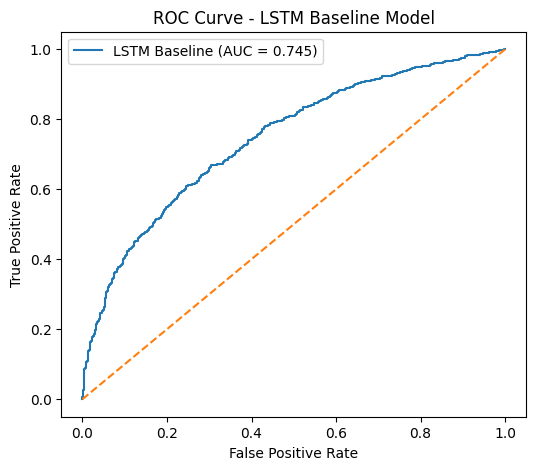

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_prob = model.predict(X_test_pad)

# If output is softmax (2 classes)
y_pred_prob = y_pred_prob[:,1]

# ROC calculations
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

print("LSTM Baseline AUC Score:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="LSTM Baseline (AUC = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LSTM Baseline Model")
plt.legend()
plt.show()

In [ ]:
loss, acc = model.evaluate(X_test_pad, y_test)

print("Baseline Test Accuracy:", acc)

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6710 - loss: 0.6119
Baseline Test Accuracy: 0.682429313659668


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Predict probabilities
y_pred_probs = model.predict(X_test_pad)

# Convert to class labels
y_pred = np.argmax(y_pred_probs, axis=1)

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[849 276]
 [409 623]]


one hot

In [ ]:
# STEP 1: text → sequence

X_train = [text_to_seq(text, vocab) for text in train_df["input_text"]]

X_val   = [text_to_seq(text, vocab) for text in val_df["input_text"]]

X_test  = [text_to_seq(text, vocab) for text in test_df["input_text"]]

In [ ]:
# STEP 2: limit vocab

max_words = 2000

X_train_oh = [[min(i, max_words-1) for i in seq] for seq in X_train]

X_val_oh   = [[min(i, max_words-1) for i in seq] for seq in X_val]

X_test_oh  = [[min(i, max_words-1) for i in seq] for seq in X_test]

In [ ]:
# STEP 3: padding

from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len_oh = 40

X_train_pad_oh = pad_sequences(X_train_oh, maxlen=max_len_oh, padding="post")

X_val_pad_oh   = pad_sequences(X_val_oh, maxlen=max_len_oh, padding="post")

X_test_pad_oh  = pad_sequences(X_test_oh, maxlen=max_len_oh, padding="post")

In [ ]:
# STEP 4

from tensorflow.keras.layers import Lambda
import tensorflow.keras.backend as K

In [ ]:
# STEP 5

vocab_size_oh = max_words

def one_hot_layer(x):

    return K.one_hot(x, vocab_size_oh)

In [ ]:
# STEP 6

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout

onehot_model = Sequential()

onehot_model.add(Input(shape=(max_len_oh,)))

onehot_model.add(Lambda(one_hot_layer))

onehot_model.add(LSTM(32, dropout=0.3, recurrent_dropout=0.3))

onehot_model.add(Dense(32, activation="relu"))

onehot_model.add(Dropout(0.3))

onehot_model.add(Dense(1, activation="sigmoid"))

onehot_model.compile(

    loss="binary_crossentropy",

    optimizer="adam",

    metrics=["accuracy"]

)

onehot_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# STEP 7

history_onehot = onehot_model.fit(

    X_train_pad_oh,
    y_train,

    validation_data=(X_val_pad_oh, y_val),

    epochs=10,

    batch_size=64

)

Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 56s 192ms/step - accuracy: 0.5318 - loss: 0.6897 - val_accuracy: 0.6174 - val_loss: 0.6633
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 51s 190ms/step - accuracy: 0.6212 - loss: 0.6608 - val_accuracy: 0.6521 - val_loss: 0.6402
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 83s 193ms/step - accuracy: 0.6463 - loss: 0.6391 - val_accuracy: 0.6617 - val_loss: 0.6238
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 52s 191ms/step - accuracy: 0.6642 - loss: 0.6250 - val_accuracy: 0.6544 - val_loss: 0.6200
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 50s 185ms/step - accuracy: 0.6680 - loss: 0.6185 - val_accuracy: 0.6489 - val_loss: 0.6227
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 51s 190ms/step - accuracy: 0.6698 - loss: 0.6117 - val_accuracy: 0.6562 - val_loss: 0.6221
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 52s 193ms/step - accuracy: 0.6821 - loss: 0.6064 - val_accuracy: 0.6557 - val_loss: 0.6207
Epoch 8/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 50s 185ms/step - accuracy: 0.6957 - loss: 0

In [ ]:
loss, acc = onehot_model.evaluate(X_test_pad_oh, y_test)

print("One Hot Test Accuracy:", acc)

68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.6641 - loss: 0.6083
One Hot Test Accuracy: 0.6666666865348816


In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = (onehot_model.predict(X_test_pad_oh) > 0.5).astype("int32")

print(confusion_matrix(y_test, y_pred))

68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step
[[754 371]
 [348 684]]


68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step
One-Hot AUC Score: 0.7206373815676141


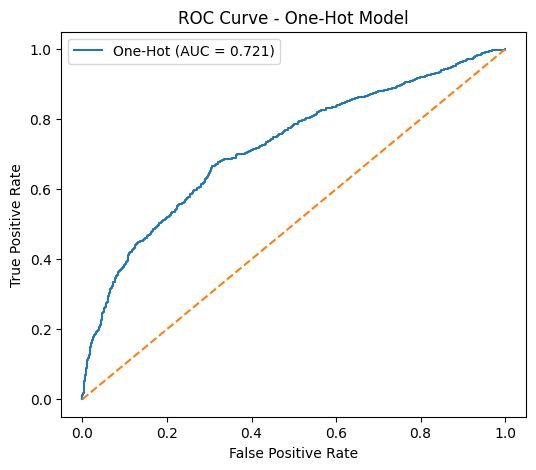

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_prob = onehot_model.predict(X_test_pad)

# Convert to 1D
y_pred_prob = y_pred_prob.ravel()

# ROC calculation
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

print("One-Hot AUC Score:", roc_auc)

# Plot ROC
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="One-Hot (AUC = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - One-Hot Model")
plt.legend()
plt.show()

GLOVE EMBEDDINGS

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 66.4 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api
import numpy as np

In [ ]:
glove = api.load("glove-twitter-100")

embedding_dim = 100

print("GloVe loaded")

[==================================================] 100.0% 387.1/387.1MB downloaded
GloVe loaded


In [ ]:
vocab_size = len(vocab)

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, index in vocab.items():

    if word in glove:

        embedding_matrix[index] = glove[word]

print("Embedding matrix ready")

Embedding matrix ready


In [ ]:
X_train_glove = X_train_pad
X_val_glove   = X_val_pad
X_test_glove  = X_test_pad

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Input, Dropout

glove_model = Sequential()

glove_model.add(Input(shape=(max_len,)))

glove_model.add(Embedding(

    input_dim=vocab_size,

    output_dim=embedding_dim,

    weights=[embedding_matrix],

    trainable=True

))

glove_model.add(LSTM(80, dropout=0.2, recurrent_dropout=0.2))

glove_model.add(Dense(32, activation="relu"))

glove_model.add(Dropout(0.2))

glove_model.add(Dense(1, activation="sigmoid"))

glove_model.compile(

    loss="binary_crossentropy",

    optimizer="adam",

    metrics=["accuracy"]

)

glove_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 100)        │       648,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 80)             │        57,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 709,345 (2.71 MB)

 Trainable params: 709,345 (2.71 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_glove = glove_model.fit(

    X_train_glove,
    y_train,

    validation_data=(X_val_glove, y_val),

    epochs=4,

    batch_size=64

)

Epoch 1/4
270/270 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.5339 - loss: 0.6845 - val_accuracy: 0.6498 - val_loss: 0.6347
Epoch 2/4
270/270 ━━━━━━━━━━━━━━━━━━━━ 25s 92ms/step - accuracy: 0.6644 - loss: 0.6219 - val_accuracy: 0.6776 - val_loss: 0.5979
Epoch 3/4
270/270 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - accuracy: 0.7128 - loss: 0.5819 - val_accuracy: 0.6845 - val_loss: 0.5989
Epoch 4/4
270/270 ━━━━━━━━━━━━━━━━━━━━ 24s 89ms/step - accuracy: 0.7296 - loss: 0.5546 - val_accuracy: 0.6890 - val_loss: 0.5893


68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step
GloVe Model AUC Score: 0.769340223944875


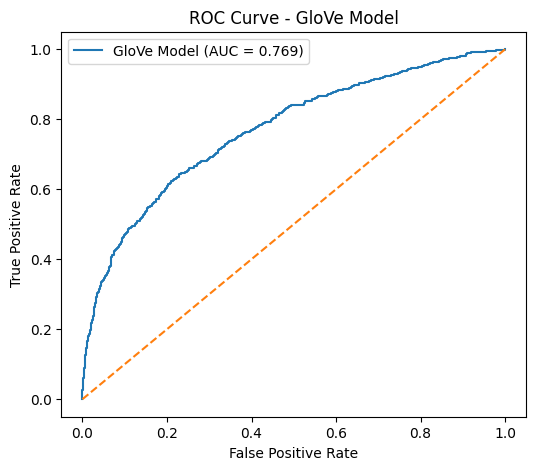

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_prob = glove_model.predict(X_test_pad)

# Convert predictions to 1D
y_pred_prob = y_pred_prob.ravel()

# ROC calculation
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

print("GloVe Model AUC Score:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="GloVe Model (AUC = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GloVe Model")
plt.legend()
plt.show()

In [ ]:
loss, acc = glove_model.evaluate(X_test_glove, y_test)

print("FINAL GLOVE TEST ACCURACY:", acc)

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6937 - loss: 0.5890
FINAL GLOVE TEST ACCURACY: 0.7014371752738953


In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = (glove_model.predict(X_test_glove) > 0.5).astype("int32")

print(confusion_matrix(y_test, y_pred))

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
[[930 195]
 [449 583]]


ATTENTION LAYER

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.models import Model

In [ ]:
class AttentionLayer(Layer):

    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):

        self.W = self.add_weight(

            name="att_weight",

            shape=(input_shape[-1], 1),

            initializer="normal"

        )

        self.b = self.add_weight(

            name="att_bias",

            shape=(input_shape[1], 1),

            initializer="zeros"

        )

        super().build(input_shape)


    def call(self, x):

        e = tf.keras.backend.tanh(

            tf.keras.backend.dot(x, self.W) + self.b

        )

        a = tf.keras.backend.softmax(e, axis=1)

        output = x * a

        return tf.keras.backend.sum(output, axis=1)

In [ ]:
input_layer = Input(shape=(max_len,))

embedding = Embedding(

    input_dim=vocab_size,

    output_dim=embedding_dim,

    weights=[embedding_matrix],

    trainable=True

)(input_layer)


lstm = LSTM(

    64,

    return_sequences=True,

    dropout=0.2,

    recurrent_dropout=0.2

)(embedding)


attention = AttentionLayer()(lstm)


dense = Dense(32, activation="relu")(attention)

drop = Dropout(0.2)(dense)

output = Dense(1, activation="sigmoid")(drop)


attention_model = Model(inputs=input_layer, outputs=output)


attention_model.compile(

    loss="binary_crossentropy",

    optimizer="adam",

    metrics=["accuracy"]

)

attention_model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 50, 100)        │       648,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50, 64)         │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ (None, 64)             │           114 │
│ (AttentionLayer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,267 (2.64 MB)

 Trainable params: 693,267 (2.64 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_att = attention_model.fit(

    X_train_glove,
    y_train,

    validation_data=(X_val_glove, y_val),

    epochs=5,

    batch_size=64

)

Epoch 1/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step - accuracy: 0.5909 - loss: 0.6648 - val_accuracy: 0.6772 - val_loss: 0.5921
Epoch 2/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 24s 88ms/step - accuracy: 0.7027 - loss: 0.5711 - val_accuracy: 0.6913 - val_loss: 0.5755
Epoch 3/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 23s 86ms/step - accuracy: 0.7417 - loss: 0.5154 - val_accuracy: 0.7073 - val_loss: 0.5647
Epoch 4/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - accuracy: 0.7848 - loss: 0.4644 - val_accuracy: 0.7082 - val_loss: 0.5815
Epoch 5/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 41s 84ms/step - accuracy: 0.8084 - loss: 0.4202 - val_accuracy: 0.7077 - val_loss: 0.5817


In [ ]:
loss, acc = attention_model.evaluate(X_test_glove, y_test)

print("FINAL ATTENTION TEST ACCURACY:", acc)

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6993 - loss: 0.5982
FINAL ATTENTION TEST ACCURACY: 0.7158089876174927


In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = (attention_model.predict(X_test_glove) > 0.5).astype("int32")

print(confusion_matrix(y_test, y_pred))

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
[[930 195]
 [418 614]]


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
y_pred_prob = attention_model.predict(X_test_glove)

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.792681309216193


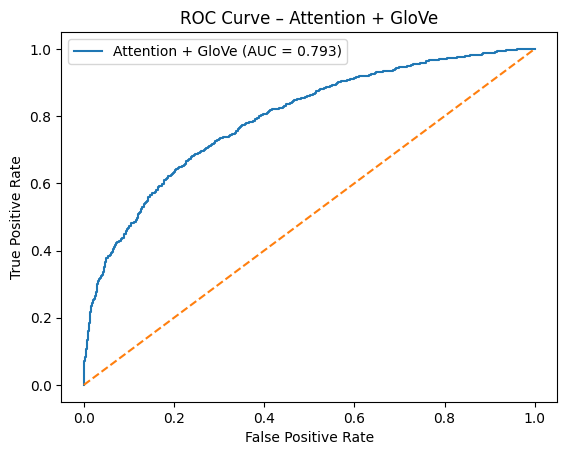

In [ ]:
plt.figure()

plt.plot(fpr, tpr, label="Attention + GloVe (AUC = %0.3f)" % roc_auc)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve – Attention + GloVe")

plt.legend()

plt.show()

BASELINE GRU

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input, Embedding, Dropout

In [ ]:
X_train_gru = X_train_pad
X_val_gru   = X_val_pad
X_test_gru  = X_test_pad

In [ ]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import GRU, Dense, Input, Embedding

# gru_model = Sequential()

# gru_model.add(Input(shape=(max_len,)))

# gru_model.add(Embedding(

#     input_dim=len(vocab),

#     output_dim=16   # reduced

# ))

# # gru_model.add(GRU(

# #     8   # reduced strongly

# # ))
# gru_model.add(GRU(8, dropout=0.3, recurrent_dropout=0.3))
# gru_model.add(Dense(1, activation="sigmoid"))

# gru_model.compile(

#     loss="binary_crossentropy",

#     optimizer="adam",

#     metrics=["accuracy"]

# )

# gru_model.summary()
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input, Embedding

gru_model = Sequential()

gru_model.add(Input(shape=(max_len,)))

gru_model.add(Embedding(

    input_dim=len(vocab),

    output_dim=16   # reduced embedding

))

gru_model.add(GRU(

    8   # reduced GRU units

))

gru_model.add(Dense(1, activation="sigmoid"))

gru_model.compile(

    loss="binary_crossentropy",

    optimizer="adam",

    metrics=["accuracy"]

)

gru_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 50, 16)         │       103,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 8)              │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,441 (407.97 KB)

 Trainable params: 104,441 (407.97 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# history_gru = gru_model.fit(

#     X_train_pad,
#     y_train,

#     validation_data=(X_val_pad, y_val),

#     epochs=4,

#     batch_size=64

# )
history_gru = gru_model.fit(

    X_train_pad,
    y_train,

    validation_data=(X_val_pad, y_val),

    epochs=3,

    batch_size=64

)

Epoch 1/3
270/270 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.5211 - loss: 0.6919 - val_accuracy: 0.5062 - val_loss: 0.6925
Epoch 2/3
270/270 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5252 - loss: 0.6873 - val_accuracy: 0.6379 - val_loss: 0.6359
Epoch 3/3
270/270 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6987 - loss: 0.5883 - val_accuracy: 0.6835 - val_loss: 0.5898


In [ ]:
# Baseline GRU Test Accuracy

loss, acc = gru_model.evaluate(X_test_pad, y_test)

print("Baseline GRU Test Accuracy:", acc)

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6763 - loss: 0.6119
Baseline GRU Test Accuracy: 0.6944831013679504


In [ ]:
# Predict class labels

y_pred_prob = gru_model.predict(X_test_pad)

y_pred = (y_pred_prob > 0.5).astype("int32")

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")

print(cm)

Confusion Matrix:

[[764 361]
 [298 734]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.68      0.70      1125
           1       0.67      0.71      0.69      1032

    accuracy                           0.69      2157
   macro avg       0.69      0.70      0.69      2157
weighted avg       0.70      0.69      0.69      2157



68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
GRU Baseline AUC Score: 0.7586675279931094


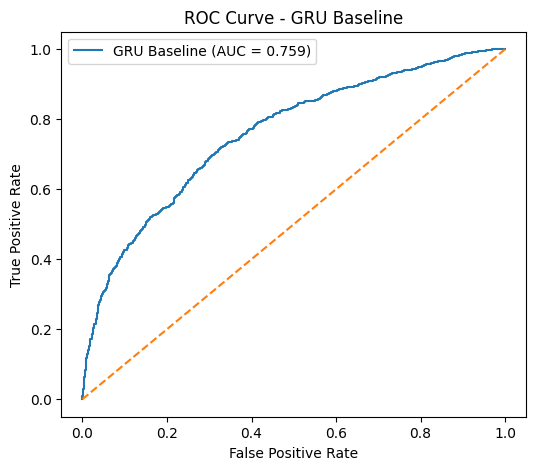

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_prob = gru_model.predict(X_test_pad)

# Convert to 1D
y_pred_prob = y_pred_prob.ravel()

# ROC calculation
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

print("GRU Baseline AUC Score:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="GRU Baseline (AUC = %0.3f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - GRU Baseline")
plt.legend()
plt.show()

ONE HOT

In [ ]:
# ONE HOT BLOCK 1: Imports

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Lambda, Dropout, GRU
from tensorflow.keras.preprocessing.sequence import pad_sequences
import tensorflow.keras.backend as K
import numpy as np

In [ ]:
# ONE HOT BLOCK 2: Convert text to sequence

X_train = [text_to_seq(text, vocab) for text in train_df["input_text"]]

X_val   = [text_to_seq(text, vocab) for text in val_df["input_text"]]

X_test  = [text_to_seq(text, vocab) for text in test_df["input_text"]]

In [ ]:
# # ONE HOT BLOCK 3: Limit vocab

# max_words = 2000

# X_train_oh = [[min(i, max_words-1) for i in seq] for seq in X_train]

# X_val_oh   = [[min(i, max_words-1) for i in seq] for seq in X_val]

# X_test_oh  = [[min(i, max_words-1) for i in seq] for seq in X_test]
max_words = 5000

X_train_oh = [[min(i, max_words-1) for i in seq] for seq in X_train]
X_val_oh   = [[min(i, max_words-1) for i in seq] for seq in X_val]
X_test_oh  = [[min(i, max_words-1) for i in seq] for seq in X_test]

In [ ]:
# ONE HOT BLOCK 4: Padding

max_len_oh = 40

X_train_pad_oh = pad_sequences(X_train_oh, maxlen=max_len_oh, padding="post")

X_val_pad_oh   = pad_sequences(X_val_oh, maxlen=max_len_oh, padding="post")

X_test_pad_oh  = pad_sequences(X_test_oh, maxlen=max_len_oh, padding="post")

In [ ]:
# # ONE HOT BLOCK 5: One Hot Layer

# vocab_size_oh = max_words

# def one_hot_layer(x):

#     return K.one_hot(x, vocab_size_oh)

In [ ]:
# # ONE HOT BLOCK 6: Model

# onehot_model = Sequential()

# onehot_model.add(Input(shape=(max_len_oh,)))

# onehot_model.add(Lambda(one_hot_layer))

# onehot_model.add(GRU(64, dropout=0.3, recurrent_dropout=0.3))

# onehot_model.add(Dense(32, activation="relu"))

# onehot_model.add(Dropout(0.3))

# onehot_model.add(Dense(1, activation="sigmoid"))

# onehot_model.compile(

#     loss="binary_crossentropy",

#     optimizer="adam",

#     metrics=["accuracy"]

# )

# onehot_model.summary()
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Lambda, GRU, TimeDistributed
import tensorflow.keras.backend as K

vocab_size_oh = max_words

def one_hot_layer(x):
    return K.one_hot(x, vocab_size_oh)

onehot_model = Sequential()

onehot_model.add(Input(shape=(max_len_oh,)))

# One-Hot
onehot_model.add(Lambda(one_hot_layer))

# Trainable projection ← THIS improves accuracy
onehot_model.add(TimeDistributed(Dense(128, activation="relu")))

# GRU
onehot_model.add(GRU(128))

# Output
onehot_model.add(Dense(1, activation="sigmoid"))

onehot_model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

onehot_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# # ONE HOT BLOCK 7: Training

# history_onehot = onehot_model.fit(

#     X_train_pad_oh,
#     y_train,

#     validation_data=(X_val_pad_oh, y_val),

#     epochs=8,

#     batch_size=64

# )
history_onehot = onehot_model.fit(
    X_train_pad_oh,
    y_train,
    validation_data=(X_val_pad_oh, y_val),
    epochs=6,
    batch_size=64
)

Epoch 1/6
270/270 ━━━━━━━━━━━━━━━━━━━━ 93s 332ms/step - accuracy: 0.5200 - loss: 0.6909 - val_accuracy: 0.5153 - val_loss: 0.6899
Epoch 2/6
270/270 ━━━━━━━━━━━━━━━━━━━━ 82s 305ms/step - accuracy: 0.5804 - loss: 0.6643 - val_accuracy: 0.6744 - val_loss: 0.6210
Epoch 3/6
270/270 ━━━━━━━━━━━━━━━━━━━━ 82s 304ms/step - accuracy: 0.7467 - loss: 0.5285 - val_accuracy: 0.6744 - val_loss: 0.6016
Epoch 4/6
270/270 ━━━━━━━━━━━━━━━━━━━━ 83s 306ms/step - accuracy: 0.7777 - loss: 0.4865 - val_accuracy: 0.6680 - val_loss: 0.6124
Epoch 5/6
270/270 ━━━━━━━━━━━━━━━━━━━━ 141s 304ms/step - accuracy: 0.8057 - loss: 0.4426 - val_accuracy: 0.6676 - val_loss: 0.6412
Epoch 6/6
270/270 ━━━━━━━━━━━━━━━━━━━━ 81s 302ms/step - accuracy: 0.8212 - loss: 0.4213 - val_accuracy: 0.6617 - val_loss: 0.6956


In [ ]:
# ONE-HOT Test Accuracy

loss, acc = onehot_model.evaluate(X_test_pad_oh, y_test)

print("One-Hot Test Accuracy:", acc)

68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 89ms/step - accuracy: 0.6799 - loss: 0.6775
One-Hot Test Accuracy: 0.6699119210243225


In [ ]:
# Predict probabilities

y_pred_prob = onehot_model.predict(X_test_pad_oh)

# Convert to class labels

y_pred = (y_pred_prob > 0.5).astype("int32")

68/68 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")

print(cm)

Confusion Matrix:

[[782 343]
 [369 663]]


68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step


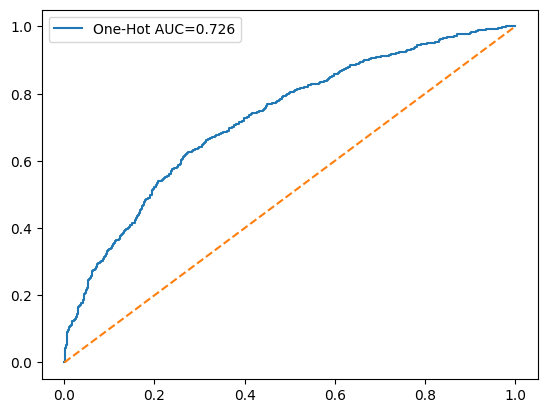

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = onehot_model.predict(X_test_pad_oh)

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="One-Hot AUC=%0.3f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.show()

GLOVE EMBEDDINGS

In [ ]:
!pip install gensim

import gensim.downloader as api
import numpy as np

In [ ]:
vocab_size = len(vocab)

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, index in vocab.items():

    if word in glove:
        embedding_matrix[index] = glove[word]

print("Embedding matrix ready")

Embedding matrix ready


In [ ]:
X_train_glove = X_train_pad
X_val_glove   = X_val_pad
X_test_glove  = X_test_pad

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout, Input

glove_model = Sequential()

glove_model.add(Input(shape=(max_len,)))

glove_model.add(Embedding(

    input_dim=vocab_size,

    output_dim=embedding_dim,

    weights=[embedding_matrix],

    trainable=True   # IMPORTANT for higher accuracy

))

glove_model.add(GRU(128, dropout=0.2, recurrent_dropout=0.2))

glove_model.add(Dense(64, activation="relu"))

glove_model.add(Dropout(0.3))

glove_model.add(Dense(1, activation="sigmoid"))

glove_model.compile(

    loss="binary_crossentropy",

    optimizer="adam",

    metrics=["accuracy"]

)

glove_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 50, 100)        │       648,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 745,441 (2.84 MB)

 Trainable params: 745,441 (2.84 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_glove = glove_model.fit(

    X_train_glove,
    y_train,

    validation_data=(X_val_glove, y_val),

    epochs=6,

    batch_size=64

)

Epoch 1/6
270/270 ━━━━━━━━━━━━━━━━━━━━ 86s 292ms/step - accuracy: 0.5126 - loss: 0.6917 - val_accuracy: 0.5303 - val_loss: 0.6902
Epoch 2/6
270/270 ━━━━━━━━━━━━━━━━━━━━ 35s 131ms/step - accuracy: 0.5681 - loss: 0.6797 - val_accuracy: 0.6689 - val_loss: 0.6181
Epoch 3/6
270/270 ━━━━━━━━━━━━━━━━━━━━ 34s 126ms/step - accuracy: 0.6830 - loss: 0.6089 - val_accuracy: 0.6822 - val_loss: 0.5966
Epoch 4/6
270/270 ━━━━━━━━━━━━━━━━━━━━ 39s 143ms/step - accuracy: 0.7389 - loss: 0.5397 - val_accuracy: 0.6945 - val_loss: 0.5742
Epoch 5/6
270/270 ━━━━━━━━━━━━━━━━━━━━ 36s 134ms/step - accuracy: 0.7785 - loss: 0.4843 - val_accuracy: 0.7050 - val_loss: 0.5937
Epoch 6/6
270/270 ━━━━━━━━━━━━━━━━━━━━ 42s 137ms/step - accuracy: 0.8014 - loss: 0.4387 - val_accuracy: 0.7104 - val_loss: 0.6043


In [ ]:
loss, acc = glove_model.evaluate(X_test_glove, y_test)

print("Final GloVe Test Accuracy:", acc)

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.7156 - loss: 0.5929
Final GloVe Test Accuracy: 0.7088549137115479


In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = (glove_model.predict(X_test_glove) > 0.5).astype("int32")

print(confusion_matrix(y_test, y_pred))

68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
[[818 307]
 [321 711]]


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [ ]:
y_prob_glove = glove_model.predict(X_test_glove)

68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_glove)

roc_auc = auc(fpr, tpr)

print("GloVe AUC Score:", roc_auc)

GloVe AUC Score: 0.7822988802756244


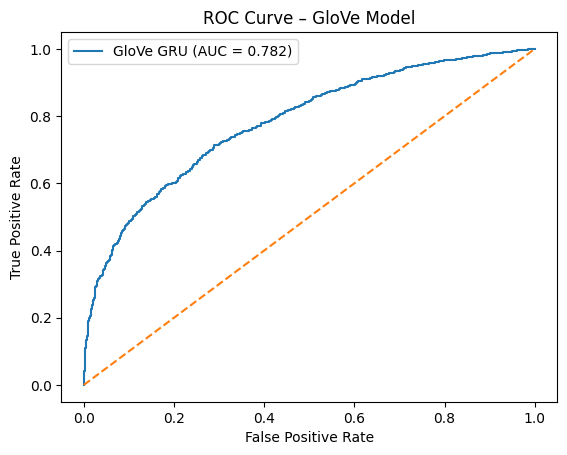

In [ ]:
plt.figure()

plt.plot(fpr, tpr, label="GloVe GRU (AUC = %0.3f)" % roc_auc)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve – GloVe Model")

plt.legend()

plt.show()

ATTENTION LAYER

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Input, Embedding, GRU, Dense, Dropout
from tensorflow.keras.models import Model

In [ ]:
class AttentionLayer(Layer):
    def __init__(self):
        super(AttentionLayer, self).__init__()

    def build(self, input_shape):

        self.W = self.add_weight(
            name="att_weight",
            shape=(input_shape[-1], 1),
            initializer="normal"
        )

        self.b = self.add_weight(
            name="att_bias",
            shape=(input_shape[1], 1),
            initializer="zeros"
        )

        super(AttentionLayer, self).build(input_shape)

    def call(self, x):

        e = tf.keras.backend.tanh(
            tf.keras.backend.dot(x, self.W) + self.b
        )

        a = tf.keras.backend.softmax(e, axis=1)

        context = x * a
        context = tf.keras.backend.sum(context, axis=1)

        return context, a

In [ ]:
input_layer = Input(shape=(max_len,))

embedding = Embedding(

    input_dim=vocab_size,
    output_dim=embedding_dim,
    weights=[embedding_matrix],
    trainable=True

)(input_layer)


gru_out = GRU(

    128,
    return_sequences=True,
    dropout=0.2,
    recurrent_dropout=0.2

)(embedding)


attention_out, attention_weights = AttentionLayer()(gru_out)


dense = Dense(64, activation="relu")(attention_out)

drop = Dropout(0.3)(dense)

output = Dense(1, activation="sigmoid")(drop)


attention_model = Model(inputs=input_layer, outputs=output)


attention_model.compile(

    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]

)

attention_model.summary()

Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_7 (Embedding)         │ (None, 50, 100)        │       648,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 50, 128)        │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer_3               │ [(None, 128), (None,   │           178 │
│ (AttentionLayer)                │ 50, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 745,619 (2.84 MB)

 Trainable params: 745,619 (2.84 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_att = attention_model.fit(

    X_train_glove,
    y_train,

    validation_data=(X_val_glove, y_val),

    epochs=5,

    batch_size=64

)

Epoch 1/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 42s 137ms/step - accuracy: 0.5865 - loss: 0.6674 - val_accuracy: 0.6863 - val_loss: 0.5858
Epoch 2/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 36s 134ms/step - accuracy: 0.7079 - loss: 0.5600 - val_accuracy: 0.6972 - val_loss: 0.5722
Epoch 3/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 41s 133ms/step - accuracy: 0.7546 - loss: 0.5030 - val_accuracy: 0.7177 - val_loss: 0.5768
Epoch 4/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 36s 134ms/step - accuracy: 0.7851 - loss: 0.4604 - val_accuracy: 0.7209 - val_loss: 0.5821
Epoch 5/5
270/270 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - accuracy: 0.8141 - loss: 0.4081 - val_accuracy: 0.7250 - val_loss: 0.5855


In [ ]:
loss, acc = attention_model.evaluate(X_test_glove, y_test)

print("Final Attention Test Accuracy:", acc)

68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7029 - loss: 0.5990
Final Attention Test Accuracy: 0.7171998023986816


In [ ]:
attention_extractor = Model(
    inputs=attention_model.input,
    outputs=attention_weights
)

In [ ]:
attention_scores = attention_extractor.predict(X_test_glove[0:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step


In [ ]:
sequence = X_test_glove[0]

words = ["token_"+str(i) for i in range(len(sequence))]

attention_scores = attention_scores[0]

In [ ]:
from sklearn.metrics import confusion_matrix

y_pred = (attention_model.predict(X_test_glove) > 0.5).astype("int32")

print("Attention Confusion Matrix:")

print(confusion_matrix(y_test, y_pred))

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
Attention Confusion Matrix:
[[875 250]
 [360 672]]


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Attention AUC: 0.7984659776055125


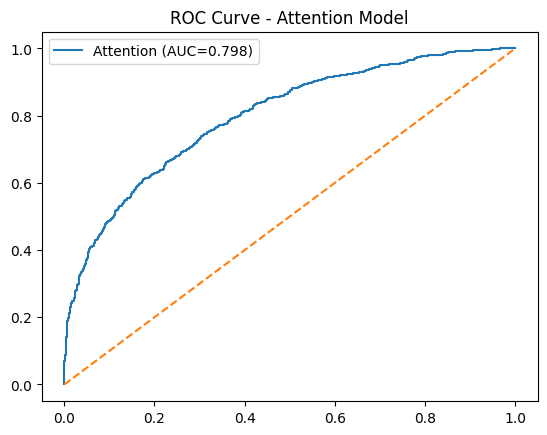

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = attention_model.predict(X_test_glove)

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("Attention AUC:", roc_auc)

plt.plot(fpr, tpr, label="Attention (AUC=%0.3f)" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve - Attention Model")
plt.show()

In [ ]:
valid_len = (X_test_glove[0] != 0).sum()

attention_scores = attention_scores[:valid_len]

words = ["token_"+str(i) for i in range(valid_len)]

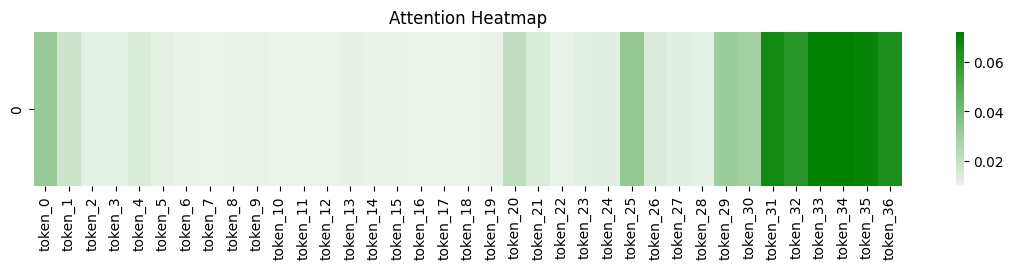

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,2))

sns.heatmap(
    attention_scores.T, # Changed from attention_scores[0].T to attention_scores.T
    cmap=sns.light_palette("green", as_cmap=True),
    xticklabels=words,
    cbar=True
)

plt.title("Attention Heatmap")
plt.xticks(rotation=90)
plt.show()

Mini-Lstm


Mini-Lstm+Glove


In [ ]:
vocab = build_vocab(train_df["input_text"])

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-03-07 03:57:18--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-07 03:57:19--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-07 03:57:19--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [ ]:
!unzip glove.6B.zip

Archive:  glove.6B.zip
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [ ]:
glove_path = "glove.6B.100d.txt"

embeddings_index = {}

with open(glove_path, encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

In [ ]:
vocab_size = len(vocab) + 1

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in vocab.items():
    vector = embeddings_index.get(word)

    if vector is not None:
        embedding_matrix[i] = vector

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

model_lstm_glove = Sequential()

model_lstm_glove.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=True
    )
)

model_lstm_glove.add(LSTM(64))

model_lstm_glove.add(Dropout(0.3))

model_lstm_glove.add(Dense(len(unique_labels), activation="softmax"))

model_lstm_glove.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_lstm_glove.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │       648,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,900 (2.48 MB)

 Trainable params: 648,900 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

MIN LSTM+GLOVE

In [ ]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from torch.utils.data import Dataset, DataLoader

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
train_df = pd.read_csv("/content/trainmerged (4).csv")
val_df = pd.read_csv("/content/valmerged (3).csv")
test_df = pd.read_csv("/content/testmerged (3).csv")

print(train_df.head())

                                               Tweet          Target   Stance
0  "Policy Over Politics" & "People Over Profits"...  Bernie Sanders    FAVOR
1  "Bernie knows"? Bernie knows it's bullshit, bu...  Bernie Sanders    FAVOR
2  Well, a sad day for all my communist friends. ...  Bernie Sanders  AGAINST
3  Back in 1995, @SenSanders used his time to cal...  Bernie Sanders    FAVOR
4  Anyone else NOT comforted by promises to get t...  Bernie Sanders  AGAINST


In [ ]:
texts = train_df['Tweet'].astype(str)
labels = train_df['Stance']

tokenizer = Tokenizer(num_words=20000)
tokenizer.fit_on_texts(texts)

X_train = tokenizer.texts_to_sequences(train_df['Tweet'])
X_val = tokenizer.texts_to_sequences(val_df['Tweet'])
X_test = tokenizer.texts_to_sequences(test_df['Tweet'])

max_len = 100

X_train = pad_sequences(X_train, maxlen=max_len)
X_val = pad_sequences(X_val, maxlen=max_len)
X_test = pad_sequences(X_test, maxlen=max_len)

y_train = train_df['Stance'].values
y_val = val_df['Stance'].values
y_test = test_df['Stance'].values

In [ ]:
print(train_df.columns)

Index(['Tweet', 'Target', 'Stance'], dtype='object')


In [ ]:
embedding_index = {}

with open("glove.6B.100d.txt", encoding='utf8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = vector

In [ ]:
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 100

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():

    vector = embedding_index.get(word)

    if vector is not None:
        embedding_matrix[i] = vector

In [ ]:
class TextDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df['Stance'] = le.fit_transform(train_df['Stance'])
val_df['Stance'] = le.transform(val_df['Stance'])
test_df['Stance'] = le.transform(test_df['Stance'])

print(le.classes_)

['AGAINST' 'FAVOR']


In [ ]:
y_train = train_df['Stance'].values
y_val = val_df['Stance'].values
y_test = test_df['Stance'].values

In [ ]:
train_dataset = TextDataset(X_train, y_train)
val_dataset = TextDataset(X_val, y_val)
test_dataset = TextDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
print(type(y_train[0]))
print(y_train[:10])

<class 'numpy.int64'>
[1 1 0 1 0 1 1 1 1 1]


In [ ]:
class MiniLSTMCell(nn.Module):

    def __init__(self, input_size, hidden_size):
        super(MiniLSTMCell, self).__init__()

        self.hidden_size = hidden_size

        self.Wz = nn.Linear(input_size + hidden_size, hidden_size)
        self.Wh = nn.Linear(input_size + hidden_size, hidden_size)
        self.Wo = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev):

        combined = torch.cat((x, h_prev), dim=1)

        z = torch.sigmoid(self.Wz(combined))

        h_tilde = torch.tanh(self.Wh(combined))

        h = (1 - z) * h_prev + z * h_tilde

        o = torch.sigmoid(self.Wo(combined))

        y = o * torch.tanh(h)

        return y

In [ ]:
class MiniLSTMModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, embedding_matrix):

        super(MiniLSTMModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
        self.embedding.weight.requires_grad = False

        self.minilstm = MiniLSTMCell(embedding_dim, hidden_size)

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        embeds = self.embedding(x)

        batch_size = x.size(0)
        h = torch.zeros(batch_size, 128).to(x.device)

        for t in range(embeds.size(1)):
            h = self.minilstm(embeds[:, t, :], h)

        out = self.fc(h)

        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MiniLSTMModel(
    vocab_size,
    embedding_dim=100,
    hidden_size=128,
    num_classes=3,
    embedding_matrix=embedding_matrix
)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import time

start_train = time.time()

epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss)

end_train = time.time()

train_time_hours = (end_train - start_train) / 3600
print("Train Time (h):", train_time_hours)

Epoch: 1 Loss: 237.99230980873108
Epoch: 2 Loss: 216.64517676830292
Epoch: 3 Loss: 192.93748204410076
Epoch: 4 Loss: 166.99328307807446
Epoch: 5 Loss: 139.6642952784896
Epoch: 6 Loss: 112.38594507053494
Epoch: 7 Loss: 87.30556849204004
Epoch: 8 Loss: 73.31118697114289
Epoch: 9 Loss: 53.477508143521845
Epoch: 10 Loss: 35.039313396438956
Train Time (h): 0.1601706643237008


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

preds = []
true = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(y_batch.numpy())

accuracy = accuracy_score(true, preds)
precision = precision_score(true, preds, average='weighted')
recall = recall_score(true, preds, average='weighted')
f1 = f1_score(true, preds, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Accuracy: 0.6495132127955494
Precision: 0.6514774972337936
Recall: 0.6495132127955494
F1: 0.6499745715091353


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
start_inf = time.time()

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

end_inf = time.time()

infer_time = end_inf - start_inf
print("Inference Time (s):", infer_time)

Inference Time (s): 3.571251392364502


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
params_million = total_params / 1e6

print("Parameters (M):", params_million)

Parameters (M): 3.136623


In [ ]:
results = {
    "Dataset": "VAST",
    "Model": "Mini-LSTM",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Train Time": train_time_hours,
    "Inference Time": infer_time,
    "Params": params_million
}

print(results)

{'Dataset': 'VAST', 'Model': 'Mini-LSTM', 'Accuracy': 0.6495132127955494, 'Precision': 0.6514774972337936, 'Recall': 0.6495132127955494, 'F1': 0.6499745715091353, 'Train Time': 0.1601706643237008, 'Inference Time': 3.571251392364502, 'Params': 3.136623}


In [ ]:
df = pd.DataFrame([results])
print(df)

  Dataset      Model  Accuracy  Precision    Recall        F1  Train Time  \
0    VAST  Mini-LSTM  0.649513   0.651477  0.649513  0.649975    0.160171   

   Inference Time    Params  
0        3.571251  3.136623  


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


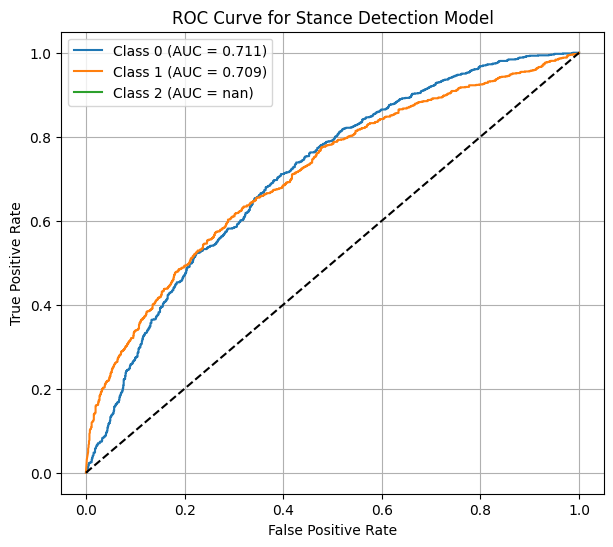

In [ ]:
# =========================
# ROC CURVE COMPLETE CODE
# =========================

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# store predictions and true labels
true_labels = []
pred_probs = []

# set model to evaluation mode
model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        # move to device (GPU/CPU)
        X_batch = X_batch.to(device)

        # model predictions
        outputs = model(X_batch)

        # convert logits to probabilities
        probabilities = torch.softmax(outputs, dim=1)

        pred_probs.extend(probabilities.cpu().numpy())
        true_labels.extend(y_batch.numpy())

# convert to numpy arrays
true_labels = np.array(true_labels)
pred_probs = np.array(pred_probs)

# number of classes
n_classes = pred_probs.shape[1]

# convert labels to binary (one-vs-rest)
true_labels_bin = label_binarize(true_labels, classes=list(range(n_classes)))

# dictionaries for ROC
fpr = dict()
tpr = dict()
roc_auc = dict()

# compute ROC for each class
for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(true_labels_bin[:, i], pred_probs[:, i])

    roc_auc[i] = auc(fpr[i], tpr[i])

# plot ROC curves
plt.figure(figsize=(7,6))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {i} (AUC = {roc_auc[i]:.3f})"
    )

# random classifier line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Stance Detection Model")
plt.legend()
plt.grid()

plt.show()

MIN LSTM+GLOVE+ATTENTION

In [ ]:
class AttentionLayer(nn.Module):

    def __init__(self, hidden_size):
        super(AttentionLayer, self).__init__()

        self.attn = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden_states):

        energy = torch.tanh(self.attn(hidden_states))

        scores = self.v(energy).squeeze(-1)

        weights = torch.softmax(scores, dim=1)

        context = torch.sum(hidden_states * weights.unsqueeze(-1), dim=1)

        return context

In [ ]:
class MiniLSTM_Attention_Model(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, embedding_matrix):

        super(MiniLSTM_Attention_Model, self).__init__()

        # GloVe embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.embedding.weight.requires_grad = False

        # MiniLSTM
        self.minilstm = MiniLSTMCell(embedding_dim, hidden_size)

        # Attention
        self.attention = AttentionLayer(hidden_size)

        # Dropout
        self.dropout = nn.Dropout(0.3)

        # Final classifier
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        embeds = self.embedding(x)

        batch_size = x.size(0)

        hidden_states = []

        h = torch.zeros(batch_size, 128).to(x.device)

        for t in range(embeds.size(1)):

            h = self.minilstm(embeds[:, t, :], h)

            hidden_states.append(h.unsqueeze(1))

        hidden_states = torch.cat(hidden_states, dim=1)

        context = self.attention(hidden_states)

        context = self.dropout(context)

        out = self.fc(context)

        return out

In [ ]:
model = MiniLSTM_Attention_Model(
    vocab_size,
    embedding_dim=100,
    hidden_size=128,
    num_classes=3,
    embedding_matrix=embedding_matrix
)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

In [ ]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -------------------------------
# TRAINING TIME START
# -------------------------------
train_start = time.time()

epochs = 15
best_val_loss = float('inf')

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # -------- validation ----------
    model.eval()
    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    scheduler.step(avg_val_loss)

    print(f"Epoch {epoch+1}")
    print("Train Loss:", avg_train_loss)
    print("Val Loss:", avg_val_loss)

# -------------------------------
# TRAINING TIME END
# -------------------------------
train_end = time.time()

train_time_hours = (train_end - train_start) / 3600

print("Training Time (hours):", train_time_hours)


# -------------------------------
# INFERENCE TIME
# -------------------------------
infer_start = time.time()

model.eval()

preds = []
true = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(y_batch.numpy())

infer_end = time.time()

infer_time_seconds = infer_end - infer_start

print("Inference Time (seconds):", infer_time_seconds)


# -------------------------------
# METRICS
# -------------------------------
accuracy = accuracy_score(true, preds)

precision = precision_score(true, preds, average='weighted')

recall = recall_score(true, preds, average='weighted')

f1 = f1_score(true, preds, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


# -------------------------------
# PARAMETER COUNT
# -------------------------------
total_params = sum(p.numel() for p in model.parameters())

params_million = total_params / 1e6

print("Parameters (M):", params_million)

Epoch 1
Train Loss: 0.6224463041837228
Val Loss: 0.6269585157650105
Epoch 2
Train Loss: 0.6040391445933998
Val Loss: 0.6227373312348905
Epoch 3
Train Loss: 0.5887067358325717
Val Loss: 0.6109408386375593
Epoch 4
Train Loss: 0.5722255941224673
Val Loss: 0.5912902515003646
Epoch 5
Train Loss: 0.5594470582225106
Val Loss: 0.5927237941735033
Epoch 6
Train Loss: 0.543629869127539
Val Loss: 0.5911566977915557
Epoch 7
Train Loss: 0.5234089742012059
Val Loss: 0.5992442075757013
Epoch 8
Train Loss: 0.5038353245090244
Val Loss: 0.6102269961350206
Epoch 9
Train Loss: 0.4767123670602331
Val Loss: 0.6046717115070509
Epoch 10
Train Loss: 0.43077363178880407
Val Loss: 0.6782904055671416
Epoch 11
Train Loss: 0.40475357117922717
Val Loss: 0.6954875752545785
Epoch 12
Train Loss: 0.37610036966862614
Val Loss: 0.7575858006442803
Epoch 13
Train Loss: 0.33480415988112205
Val Loss: 0.7963605782260066
Epoch 14
Train Loss: 0.3158419440070198
Val Loss: 0.8347649548364722
Epoch 15
Train Loss: 0.29794319356914356

In [ ]:
import pandas as pd

results = {
    "Dataset": "VAST",
    "Model": "Mini-LSTM + Attention",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Train Time (h)": train_time_hours,
    "Infer (s)": infer_time_seconds,
    "Params (M)": params_million
}

# print dictionary
print(results)

# convert to dataframe
df = pd.DataFrame([results])

# display table
print(df)

{'Dataset': 'VAST', 'Model': 'Mini-LSTM + Attention', 'Accuracy': 0.6764024107556792, 'Precision': 0.6762505462844751, 'Recall': 0.6764024107556792, 'F1-Score': 0.6762979659593575, 'Train Time (h)': 0.29336670378843943, 'Infer (s)': 2.4539525508880615, 'Params (M)': 3.153263}
  Dataset                  Model  Accuracy  Precision    Recall  F1-Score  \
0    VAST  Mini-LSTM + Attention  0.676402   0.676251  0.676402  0.676298   

   Train Time (h)  Infer (s)  Params (M)  
0        0.293367   2.453953    3.153263  


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


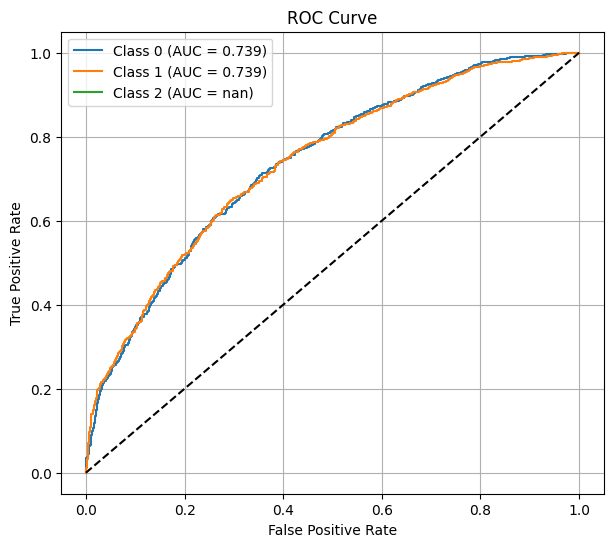

Average AUC: nan
{'Dataset': 'VAST', 'Model': 'Mini-LSTM + Attention', 'ROC-AUC': np.float64(nan)}
  Dataset                  Model  ROC-AUC
0    VAST  Mini-LSTM + Attention      NaN


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import torch

model.eval()

true_labels = []
pred_probs = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        probabilities = torch.softmax(outputs, dim=1)

        pred_probs.extend(probabilities.cpu().numpy())
        true_labels.extend(y_batch.numpy())

true_labels = np.array(true_labels)
pred_probs = np.array(pred_probs)

# number of classes
n_classes = pred_probs.shape[1]

# convert labels to binary
true_labels_bin = label_binarize(true_labels, classes=list(range(n_classes)))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(true_labels_bin[:, i], pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC
plt.figure(figsize=(7,6))

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} (AUC = {roc_auc[i]:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()

plt.show()

# Average AUC
avg_auc = np.mean(list(roc_auc.values()))

print("Average AUC:", avg_auc)

# Store in results dictionary
roc_results = {
    "Dataset": "VAST",
    "Model": "Mini-LSTM + Attention",
    "ROC-AUC": avg_auc
}

print(roc_results)

df_roc = pd.DataFrame([roc_results])
print(df_roc)

MIN GRU+GLOVE EMBEDDINGS

In [ ]:
import torch
import torch.nn as nn

class MiniGRUCell(nn.Module):

    def __init__(self, input_size, hidden_size):
        super(MiniGRUCell, self).__init__()

        self.hidden_size = hidden_size

        # update gate
        self.Wz = nn.Linear(input_size + hidden_size, hidden_size)

        # candidate hidden state
        self.Wh = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev):

        combined = torch.cat((x, h_prev), dim=1)

        z = torch.sigmoid(self.Wz(combined))

        h_tilde = torch.tanh(self.Wh(combined))

        h = (1 - z) * h_prev + z * h_tilde

        return h

In [ ]:
class MiniGRUModel(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, embedding_matrix):

        super(MiniGRUModel, self).__init__()

        # GloVe embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.embedding.weight.requires_grad = False

        # MiniGRU
        self.minigru = MiniGRUCell(embedding_dim, hidden_size)

        # dropout
        self.dropout = nn.Dropout(0.3)

        # classifier
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        embeds = self.embedding(x)

        batch_size = x.size(0)

        h = torch.zeros(batch_size, 128).to(x.device)

        for t in range(embeds.size(1)):

            h = self.minigru(embeds[:, t, :], h)

        h = self.dropout(h)

        out = self.fc(h)

        return out

In [ ]:
model = MiniGRUModel(
    vocab_size,
    embedding_dim=100,
    hidden_size=128,
    num_classes=3,
    embedding_matrix=embedding_matrix
)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# TRAINING START TIME
# -----------------------------
train_start = time.time()

epochs = 15

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        # gradient clipping for RNN stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # -----------------------------
    # VALIDATION
    # -----------------------------
    model.eval()
    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print(f"Epoch {epoch+1}")
    print("Train Loss:", avg_train_loss)
    print("Val Loss:", avg_val_loss)


# -----------------------------
# TRAINING TIME
# -----------------------------
train_end = time.time()

train_time_hours = (train_end - train_start) / 3600

print("Training Time (hours):", train_time_hours)


# -----------------------------
# INFERENCE TIME + PREDICTIONS
# -----------------------------
infer_start = time.time()

model.eval()

preds = []
true = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(y_batch.numpy())

infer_end = time.time()

infer_time_seconds = infer_end - infer_start

print("Inference Time (seconds):", infer_time_seconds)


# -----------------------------
# METRICS
# -----------------------------
accuracy = accuracy_score(true, preds)

precision = precision_score(true, preds, average='weighted')

recall = recall_score(true, preds, average='weighted')

f1 = f1_score(true, preds, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


# -----------------------------
# PARAMETER COUNT
# -----------------------------
total_params = sum(p.numel() for p in model.parameters())

params_million = total_params / 1e6

print("Parameters (M):", params_million)

Epoch 1
Train Loss: 0.6592995422116459
Val Loss: 0.6231538113476573
Epoch 2
Train Loss: 0.6065827697128444
Val Loss: 0.6047795458116393
Epoch 3
Train Loss: 0.5892421041990256
Val Loss: 0.6008832597214243
Epoch 4
Train Loss: 0.5719716442759272
Val Loss: 0.5886078001796335
Epoch 5
Train Loss: 0.5503018860582518
Val Loss: 0.5886620481808981
Epoch 6
Train Loss: 0.5296663824945743
Val Loss: 0.5937806225341299
Epoch 7
Train Loss: 0.5094655515532768
Val Loss: 0.6079654892285665
Epoch 8
Train Loss: 0.47678963809597247
Val Loss: 0.6290806359139042
Epoch 9
Train Loss: 0.4348231193528326
Val Loss: 0.663105830334235
Epoch 10
Train Loss: 0.38637038650671934
Val Loss: 0.6990063682846401
Epoch 11
Train Loss: 0.3463528201066939
Val Loss: 0.7854807368223218
Epoch 12
Train Loss: 0.28453652370299504
Val Loss: 0.8575425024913705
Epoch 13
Train Loss: 0.25235409711890183
Val Loss: 1.0457596400941627
Epoch 14
Train Loss: 0.2001266960738873
Val Loss: 1.1458048116469728
Epoch 15
Train Loss: 0.16527073529889333

In [ ]:
import pandas as pd

results = {
    "Dataset": "VAST",
    "Model": "Mini-GRU",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "Train Time": train_time_hours,
    "Inference Time": infer_time_seconds,
    "Params": params_million
}

df = pd.DataFrame([results])
print(df)

  Dataset     Model  Accuracy  Precision    Recall        F1  Train Time  \
0    VAST  Mini-GRU  0.661103   0.661411  0.661103  0.661206     0.20391   

   Inference Time    Params  
0         2.39942  3.107311  


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


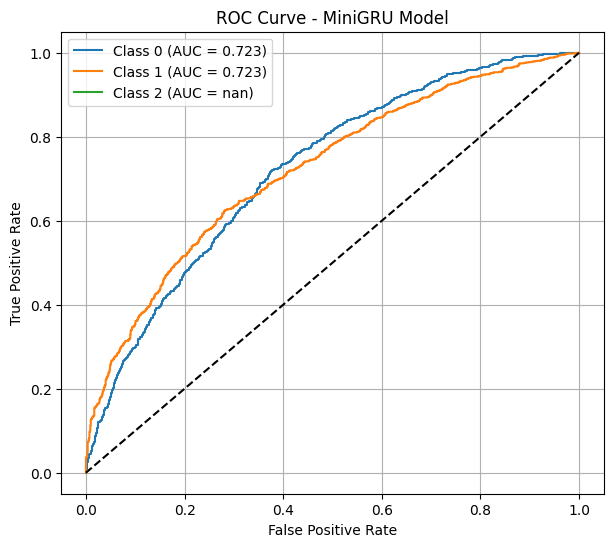

Average ROC AUC: nan


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import torch

model.eval()

true_labels = []
pred_probs = []

# Get predictions
with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        probabilities = torch.softmax(outputs, dim=1)

        pred_probs.extend(probabilities.cpu().numpy())
        true_labels.extend(y_batch.numpy())

true_labels = np.array(true_labels)
pred_probs = np.array(pred_probs)

# Number of classes
n_classes = pred_probs.shape[1]

# Convert labels to binary
true_labels_bin = label_binarize(true_labels, classes=list(range(n_classes)))

fpr = {}
tpr = {}
roc_auc = {}

# Compute ROC
for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(true_labels_bin[:, i], pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(7,6))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {i} (AUC = {roc_auc[i]:.3f})"
    )

# random classifier line
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MiniGRU Model")
plt.legend()
plt.grid()

plt.show()

# Average AUC
avg_auc = np.mean(list(roc_auc.values()))

print("Average ROC AUC:", avg_auc)

In [ ]:
import torch
import torch.nn as nn

class AttentionLayer(nn.Module):

    def __init__(self, hidden_size):
        super(AttentionLayer, self).__init__()

        self.attn = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden_states):

        energy = torch.tanh(self.attn(hidden_states))

        scores = self.v(energy).squeeze(-1)

        weights = torch.softmax(scores, dim=1)

        context = torch.sum(hidden_states * weights.unsqueeze(-1), dim=1)

        return context

In [ ]:
class MiniGRUCell(nn.Module):

    def __init__(self, input_size, hidden_size):
        super(MiniGRUCell, self).__init__()

        self.Wz = nn.Linear(input_size + hidden_size, hidden_size)
        self.Wh = nn.Linear(input_size + hidden_size, hidden_size)

    def forward(self, x, h_prev):

        combined = torch.cat((x, h_prev), dim=1)

        z = torch.sigmoid(self.Wz(combined))

        h_tilde = torch.tanh(self.Wh(combined))

        h = (1 - z) * h_prev + z * h_tilde

        return h

In [ ]:
class MiniGRU_Attention_Model(nn.Module):

    def __init__(self, vocab_size, embedding_dim, hidden_size, num_classes, embedding_matrix):

        super(MiniGRU_Attention_Model, self).__init__()

        # GloVe embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.embedding.weight.requires_grad = False

        # MiniGRU
        self.minigru = MiniGRUCell(embedding_dim, hidden_size)

        # Attention
        self.attention = AttentionLayer(hidden_size)

        # Dropout
        self.dropout = nn.Dropout(0.3)

        # Output layer
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):

        embeds = self.embedding(x)

        batch_size = x.size(0)

        hidden_states = []

        h = torch.zeros(batch_size, 128).to(x.device)

        for t in range(embeds.size(1)):

            h = self.minigru(embeds[:, t, :], h)

            hidden_states.append(h.unsqueeze(1))

        hidden_states = torch.cat(hidden_states, dim=1)

        context = self.attention(hidden_states)

        context = self.dropout(context)

        out = self.fc(context)

        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

vocab_size = len(tokenizer.word_index) + 1

model = MiniGRU_Attention_Model(
    vocab_size,
    embedding_dim=100,
    hidden_size=128,
    num_classes=3,
    embedding_matrix=embedding_matrix
)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
import time

train_start = time.time()

epochs = 15

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    print("Epoch:", epoch+1)
    print("Train Loss:", avg_train_loss)
    print("Val Loss:", avg_val_loss)

train_end = time.time()

train_time_hours = (train_end - train_start) / 3600

print("Training Time (hours):", train_time_hours)

Epoch: 1
Train Loss: 0.6708120587031341
Val Loss: 0.6348443860593049
Epoch: 2
Train Loss: 0.6109737172197544
Val Loss: 0.619520454303078
Epoch: 3
Train Loss: 0.5869924000331334
Val Loss: 0.5985373124696206
Epoch: 4
Train Loss: 0.5665218011788844
Val Loss: 0.6194804004137067
Epoch: 5
Train Loss: 0.546239238557214
Val Loss: 0.5989369909832443
Epoch: 6
Train Loss: 0.5198010993578881
Val Loss: 0.6262516673060431
Epoch: 7
Train Loss: 0.4925671946361025
Val Loss: 0.6263825759507607
Epoch: 8
Train Loss: 0.4584784377815551
Val Loss: 0.6476326908754266
Epoch: 9
Train Loss: 0.41059637429099355
Val Loss: 0.6970178735428962
Epoch: 10
Train Loss: 0.3601558196024904
Val Loss: 0.7642636035663494
Epoch: 11
Train Loss: 0.3106925075040899
Val Loss: 0.8367969372134277
Epoch: 12
Train Loss: 0.2613479392274744
Val Loss: 0.969146125126576
Epoch: 13
Train Loss: 0.22037760569871245
Val Loss: 1.12145941067433
Epoch: 14
Train Loss: 0.18185541486101492
Val Loss: 1.2641922477362812
Epoch: 15
Train Loss: 0.1771515

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

infer_start = time.time()

model.eval()

preds = []
true = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(y_batch.numpy())

infer_end = time.time()

infer_time_seconds = infer_end - infer_start

accuracy = accuracy_score(true, preds)
precision = precision_score(true, preds, average='weighted')
recall = recall_score(true, preds, average='weighted')
f1 = f1_score(true, preds, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Inference Time:", infer_time_seconds)

Accuracy: 0.6467315716272601
Precision: 0.6463661514744758
Recall: 0.6467315716272601
F1 Score: 0.6463260906654086
Inference Time: 4.519156455993652


In [ ]:
total_params = sum(p.numel() for p in model.parameters())

params_million = total_params / 1e6

print("Parameters (M):", params_million)

Parameters (M): 3.123951


In [ ]:
import pandas as pd

results = {
"Dataset":"VAST",
"Model":"MiniGRU + Attention",
"Accuracy":accuracy,
"Precision":precision,
"Recall":recall,
"F1":f1,
"Train Time":train_time_hours,
"Inference Time":infer_time_seconds,
"Params":params_million
}

df = pd.DataFrame([results])

print(df)

  Dataset                Model  Accuracy  Precision    Recall        F1  \
0    VAST  MiniGRU + Attention  0.646732   0.646366  0.646732  0.646326   

   Train Time  Inference Time    Params  
0    0.250073        4.519156  3.123951  


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1188: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


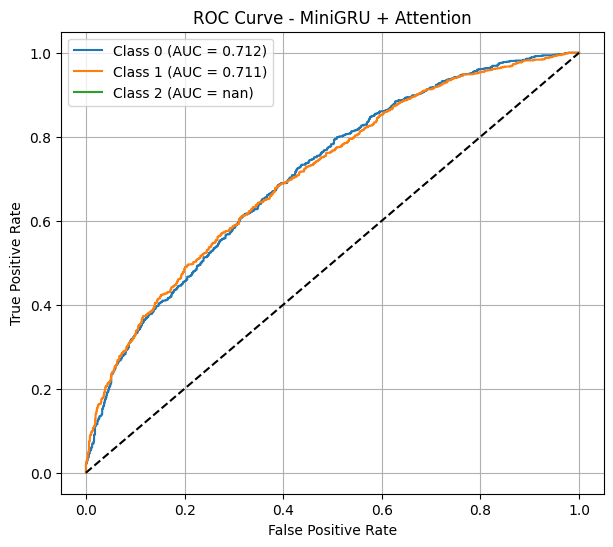

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

model.eval()

true_labels = []
pred_probs = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        probabilities = torch.softmax(outputs, dim=1)

        pred_probs.extend(probabilities.cpu().numpy())
        true_labels.extend(y_batch.numpy())

true_labels = np.array(true_labels)
pred_probs = np.array(pred_probs)

# number of classes
n_classes = pred_probs.shape[1]

# convert labels to binary
true_labels_bin = label_binarize(true_labels, classes=list(range(n_classes)))

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(true_labels_bin[:, i], pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# plot ROC
plt.figure(figsize=(7,6))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"Class {i} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MiniGRU + Attention")
plt.legend()
plt.grid()

plt.show()

In [ ]:
!pip install transformers

In [ ]:
import torch
import torch.nn as nn
import time
import pandas as pd

from transformers import BertTokenizer, BertModel
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
class BertDataset(torch.utils.data.Dataset):

    def __init__(self, texts, labels, tokenizer, max_len=128):

        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        return input_ids, attention_mask, torch.tensor(label)

In [ ]:
train_dataset = BertDataset(train_df['Tweet'].values, y_train, tokenizer)
val_dataset = BertDataset(val_df['Tweet'].values, y_val, tokenizer)
test_dataset = BertDataset(test_df['Tweet'].values, y_test, tokenizer)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [ ]:
class BertClassifier(nn.Module):

    def __init__(self, num_classes):

        super(BertClassifier, self).__init__()

        self.bert = BertModel.from_pretrained('bert-base-uncased')

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(768, num_classes)

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.pooler_output

        x = self.dropout(cls_output)

        out = self.fc(x)

        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertClassifier(num_classes=3)

model = model.to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

In [ ]:
train_start = time.time()

epochs = 3

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for input_ids, attention_mask, labels in train_loader:

        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss)

train_end = time.time()

train_time_hours = (train_end - train_start)/3600

print("Training Time:", train_time_hours)


KeyboardInterrupt



Epoch: 1 Batch: 0 Loss: 1.1254533529281616
Epoch: 1 Batch: 20 Loss: 0.7670513987541199
Epoch: 1 Batch: 40 Loss: 0.6734924912452698
Epoch: 1 Batch: 60 Loss: 0.6828582286834717
Epoch: 1 Batch: 80 Loss: 0.6673669219017029
Epoch: 1 Batch: 100 Loss: 0.4884929358959198
Epoch: 1 Batch: 120 Loss: 0.5772200226783752
Epoch: 1 Batch: 140 Loss: 0.6932867765426636
Epoch: 1 Batch: 160 Loss: 0.5151070356369019
Epoch: 1 Batch: 180 Loss: 0.643685519695282
Epoch: 1 Batch: 200 Loss: 0.44477853178977966
Epoch: 1 Batch: 220 Loss: 0.45842283964157104
Epoch: 1 Batch: 240 Loss: 0.6039102673530579
Epoch: 1 Batch: 260 Loss: 0.4405665099620819
Epoch: 1 Batch: 280 Loss: 0.495114803314209
Epoch: 1 Batch: 300 Loss: 0.5741128325462341
